<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_03/03_ED_Listas_Interfaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estructuras de Datos: Listas e Interfaces
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Estructuras de Datos
---


## Índice de Contenido
1. La Interfaz List y Abstracción
2. Listas Basadas en Arreglos (`ListArray`): Construcción Progresiva
   - 2.1. Inserción (Shift Derecha)
   - 2.2. Eliminación (Shift Izquierda)
   - 2.3. Acceso Directo (Get)
   - 2.4. Búsqueda (Search)
3. Introducción a Listas Enlazadas (`Node`)
4. Ejercicio Práctico: Push y Pop en Lista Enlazada
5. Conceptos Avanzados: Análisis y Limitaciones
6. Bibliografía
---


## 1. La Interfaz List y Abstracción

En Ciencias de la Computación, la **abstracción** nos permite separar *qué* hace una estructura de datos de *cómo* lo hace. Por ejemplo, sabemos que a una "Lista" le podemos agregar elementos, borrarlos o buscarlos, sin importarnos si internamente usa arreglos, punteros o magia.

En Java, esto se logra mediante una `interface`. Una interfaz es un contrato que deﬁne los métodos obligatorios que cualquier clase que afirme ser una lista debe implementar.


In [1]:
%%writefile ListInterface.java
// Interfaz que define el comportamiento abstracto de cualquier Lista
public interface ListInterface {
    // Inserta un valor en una posición específica
    void insert(int index, int value);

    // Elimina el elemento en una posición específica
    void delete(int index);

    // Obtiene el elemento en un índice
    int get(int index);

    // Busca un valor y retorna su índice (o -1 si no existe)
    int search(int value);

    // Imprime los elementos de la lista
    void printList();
}


Writing ListInterface.java


In [2]:
%%writefile PruebaInterfaz.java
public class PruebaInterfaz {
    public static void main(String[] args) {
        System.out.println("La interfaz ListInterface ha sido compilada. Es solo un contrato.");
    }
}


Writing PruebaInterfaz.java


In [3]:
!javac ListInterface.java PruebaInterfaz.java
!java PruebaInterfaz


[0.021s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.021s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
La interfaz ListInterface ha sido compilada. Es solo un contrato.


## 2. Listas Basadas en Arreglos (`ListArray`): Construcción Progresiva

La forma más tradicional de implementar nuestra `ListInterface` es utilizando un Arreglo estándar (`array`). Como los arreglos ocupan un bloque de memoria **contiguo** y de tamaño fijo, presentan retos fundamentales que iremos resolviendo paso a paso.


### 2.1. Inserción y el Desplazamiento (Shift Derecha)

Si queremos insertar un elemento en el medio (o al inicio) de una lista, debemos mover todos los elementos posteriores una posición hacia la derecha para hacerle espacio.

![Desplazamiento en Arreglo](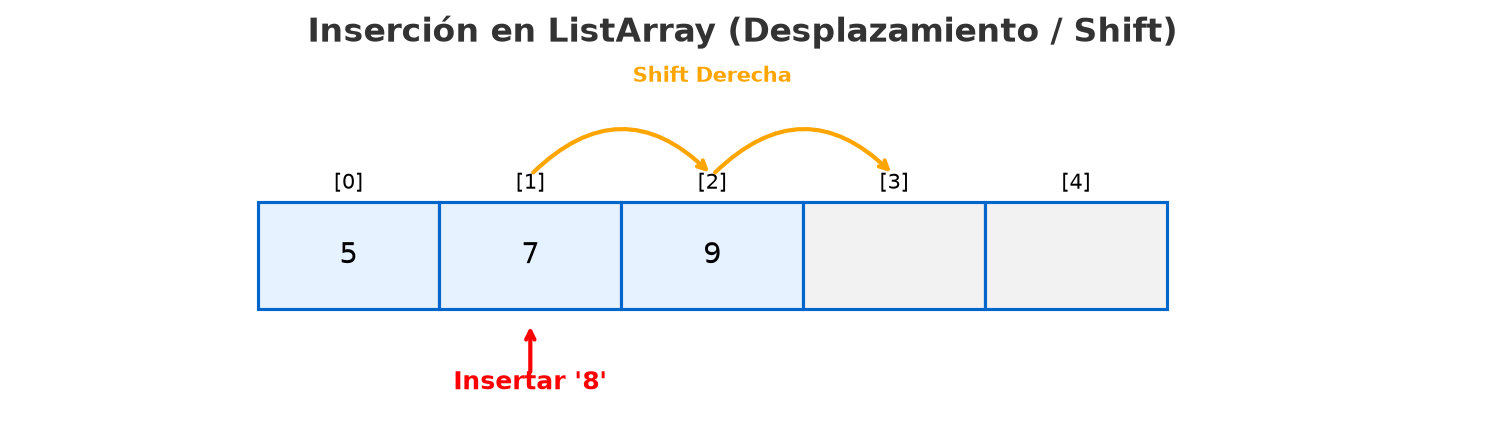 "Shift")

*Figura 1: Al insertar un nuevo elemento, los datos existentes deben desplazarse (shift) hacia la derecha.*

Implementemos primero el método `insert` (dejaremos los demás métodos vacíos temporalmente para cumplir el contrato):


In [4]:
%%writefile ListArray.java
public class ListArray implements ListInterface {
    protected int[] data;
    protected int count; // Mantiene el conteo de cuántos elementos reales hay

    public ListArray(int capacity) {
        data = new int[capacity];
        count = 0;
    }

    public void insert(int index, int value) {
        if (count >= data.length) {
            System.out.println("Error: La lista está llena.");
            return;
        }
        if (index < 0 || index > count) {
            System.out.println("Error: Índice fuera de rango.");
            return;
        }

        // 1. Desplazamiento (Shift) hacia la derecha
        for (int i = count; i > index; i--) {
            data[i] = data[i - 1];
        }

        // 2. Insertar el nuevo valor
        data[index] = value;
        count++;
    }

    public void printList() {
        System.out.print("ListArray: [ ");
        for (int i = 0; i < count; i++) {
            System.out.print(data[i] + " ");
        }
        System.out.println("]");
    }

    // Métodos temporales vacíos
    public void delete(int index) { System.out.println("Aún no implementado"); }
    public int get(int index) { return -1; }
    public int search(int value) { return -1; }
}


Writing ListArray.java


In [5]:
%%writefile PruebaInsert.java
public class PruebaInsert {
    public static void main(String[] args) {
        ListInterface miLista = new ListArray(5);
        miLista.insert(0, 5);
        miLista.insert(1, 9);
        System.out.println("Antes de insertar en el medio:");
        miLista.printList();

        miLista.insert(1, 7); // Inserta el 7 en el índice 1. El 9 debe hacer shift a la derecha
        System.out.println("\nDespués de insertar el 7:");
        miLista.printList();
    }
}


Writing PruebaInsert.java


In [6]:
!javac ListArray.java PruebaInsert.java
!java PruebaInsert


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Antes de insertar en el medio:
ListArray: [ 5 9 ]

Después de insertar el 7:
ListArray: [ 5 7 9 ]


### 2.2. Eliminación (Shift Izquierda)

De manera similar, cuando borramos un elemento del medio, nos queda un espacio en blanco. Para que el arreglo siga siendo un bloque contiguo sin huecos, debemos desplazar todos los elementos posteriores una posición hacia la **izquierda**.

Actualicemos nuestra clase para incluir el método `delete`:


In [7]:
%%writefile ListArray.java
public class ListArray implements ListInterface {
    protected int[] data;
    protected int count;

    public ListArray(int capacity) {
        data = new int[capacity];
        count = 0;
    }

    public void insert(int index, int value) {
        if (count >= data.length) return;
        for (int i = count; i > index; i--) data[i] = data[i - 1];
        data[index] = value;
        count++;
    }

    // --- NUEVO MÉTODO DELETE ---
    public void delete(int index) {
        if (index < 0 || index >= count) {
            System.out.println("Error: Índice inválido.");
            return;
        }
        // Desplazamiento (Shift) hacia la izquierda
        for (int i = index; i < count - 1; i++) {
            data[i] = data[i + 1];
        }
        count--; // Reducimos el conteo total
    }

    public void printList() {
        System.out.print("ListArray: [ ");
        for (int i = 0; i < count; i++) System.out.print(data[i] + " ");
        System.out.println("]");
    }

    public int get(int index) { return -1; }
    public int search(int value) { return -1; }
}


Overwriting ListArray.java


In [8]:
%%writefile PruebaDelete.java
public class PruebaDelete {
    public static void main(String[] args) {
        ListInterface miLista = new ListArray(5);
        miLista.insert(0, 5);
        miLista.insert(1, 7);
        miLista.insert(2, 9);
        System.out.println("Lista original:");
        miLista.printList();

        miLista.delete(0); // Borramos el primero (5). El 7 y el 9 deben hacer shift a la izquierda
        System.out.println("\nDespués de borrar el índice 0:");
        miLista.printList();
    }
}


Writing PruebaDelete.java


In [9]:
!javac ListArray.java PruebaDelete.java
!java PruebaDelete


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Lista original:
ListArray: [ 5 7 9 ]

Después de borrar el índice 0:
ListArray: [ 7 9 ]


### 2.3. Acceso Directo (Get)

La gran ventaja de los arreglos contiguos es que podemos acceder a cualquier elemento inmediatamente mediante un cálculo matemático en la memoria. No necesitamos iterar para llegar al índice 1000, simplemente saltamos hacia allá. Esto se llama acceso $O(1)$.


In [10]:
%%writefile ListArray.java
public class ListArray implements ListInterface {
    protected int[] data;
    protected int count;

    public ListArray(int capacity) {
        data = new int[capacity];
        count = 0;
    }

    public void insert(int index, int value) {
        if (count >= data.length) return;
        for (int i = count; i > index; i--) data[i] = data[i - 1];
        data[index] = value;
        count++;
    }

    public void delete(int index) {
        if (index < 0 || index >= count) return;
        for (int i = index; i < count - 1; i++) data[i] = data[i + 1];
        count--;
    }

    // --- NUEVO MÉTODO GET ---
    public int get(int index) {
        if (index < 0 || index >= count) {
            System.out.println("Error: Índice inválido.");
            return -1;
        }
        return data[index]; // Acceso inmediato en O(1)
    }

    public void printList() {
        System.out.print("ListArray: [ ");
        for (int i = 0; i < count; i++) System.out.print(data[i] + " ");
        System.out.println("]");
    }

    public int search(int value) { return -1; }
}


Overwriting ListArray.java


In [11]:
%%writefile PruebaGet.java
public class PruebaGet {
    public static void main(String[] args) {
        ListInterface miLista = new ListArray(5);
        miLista.insert(0, 100);
        miLista.insert(1, 200);
        miLista.insert(2, 300);

        System.out.println("El elemento en el índice 1 es: " + miLista.get(1));
    }
}


Writing PruebaGet.java


In [12]:
!javac ListArray.java PruebaGet.java
!java PruebaGet


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
El elemento en el índice 1 es: 200


### 2.4. Búsqueda Secuencial (Search)

Finalmente, si queremos encontrar en qué índice está un número, y la lista **no está ordenada**, nuestra única opción es buscar casilla por casilla desde el principio hasta el final. Esto toma tiempo $O(n)$.


In [13]:
%%writefile ListArray.java
public class ListArray implements ListInterface {
    protected int[] data;
    protected int count;

    public ListArray(int capacity) {
        data = new int[capacity];
        count = 0;
    }

    public void insert(int index, int value) {
        if (count >= data.length) return;
        for (int i = count; i > index; i--) data[i] = data[i - 1];
        data[index] = value;
        count++;
    }

    public void delete(int index) {
        if (index < 0 || index >= count) return;
        for (int i = index; i < count - 1; i++) data[i] = data[i + 1];
        count--;
    }

    public int get(int index) {
        if (index >= 0 && index < count) return data[index];
        return -1;
    }

    // --- NUEVO MÉTODO SEARCH ---
    public int search(int value) {
        // Búsqueda Secuencial
        for (int i = 0; i < count; i++) {
            if (data[i] == value) {
                return i; // Retorna el índice donde lo encontró
            }
        }
        return -1; // No se encontró
    }

    public void printList() {
        System.out.print("ListArray final: [ ");
        for (int i = 0; i < count; i++) System.out.print(data[i] + " ");
        System.out.println("]");
    }
}


Overwriting ListArray.java


In [14]:
%%writefile PruebaSearch.java
public class PruebaSearch {
    public static void main(String[] args) {
        ListInterface miLista = new ListArray(5);
        miLista.insert(0, 15);
        miLista.insert(1, 25);
        miLista.insert(2, 35);
        miLista.printList();

        System.out.println("Buscando el número 25...");
        int idx = miLista.search(25);
        System.out.println("Se encontró en el índice: " + idx);
    }
}


Writing PruebaSearch.java


In [15]:
!javac ListArray.java PruebaSearch.java
!java PruebaSearch


[0.003s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
ListArray final: [ 15 25 35 ]
Buscando el número 25...
Se encontró en el índice: 1


---
## 3. Introducción a Listas Enlazadas (`Node`)

Como notó en el `ListArray`, insertar al principio de la lista requiere mover absolutamente todos los demás elementos, lo cual es muy lento (Complejidad $O(n)$).

Para solucionar esto, utilizamos **Listas Enlazadas** (Linked Lists). En lugar de usar un arreglo de tamaño fijo, creamos pequeños objetos en memoria llamados **Nodos**. Cada nodo guarda el dato y un puntero (referencia) al siguiente nodo, esparciéndolos por toda la memoria de la computadora de forma dinámica.

![Lista Enlazada](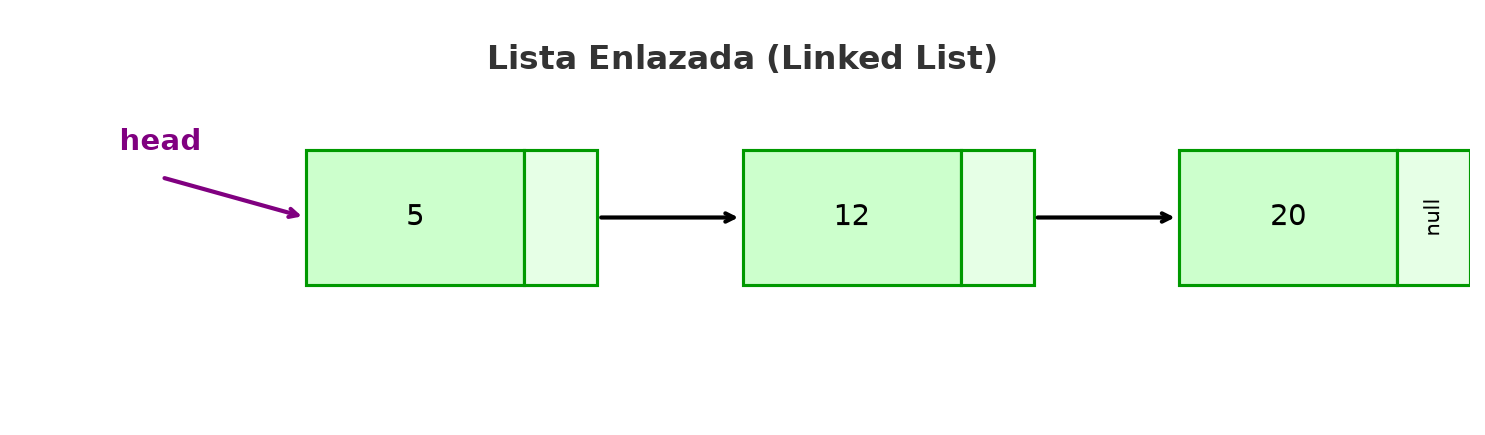 "Gráfico de Lista Enlazada")

*Figura 2: Un puntero principal `head` apunta al primer nodo. Cada nodo apunta al siguiente hasta llegar a `null`.*

A continuación, definimos la estructura más elemental de un Nodo para almacenar enteros:


In [16]:
%%writefile Node.java
public class Node {
    public int data;
    public Node next;

    // Constructor
    public Node(int data) {
        this.data = data;
        this.next = null;
    }
}


Writing Node.java


In [17]:
%%writefile PruebaNode.java
public class PruebaNode {
    public static void main(String[] args) {
        // Creación manual de la lista de la Figura 2
        Node head = new Node(5);
        head.next = new Node(12);

        System.out.println("Nodo 1: " + head.data);
        System.out.println("Nodo 2: " + head.next.data);
    }
}


Writing PruebaNode.java


In [18]:
!javac Node.java PruebaNode.java
!java PruebaNode


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Nodo 1: 5
Nodo 2: 12


---
## 4. Operaciones Básicas en Listas Enlazadas: Push y Pop

Las operaciones de insertar elementos al inicio y removerlos del inicio son tan comunes que reciben nombres especiales: **Push** y **Pop**. Exploraremos estos conceptos a fondo en la próxima clase (Pilas/Stacks), pero su mecánica en Listas Enlazadas es fascinante porque, a diferencia de los Arreglos, **no requieren hacer desplazamientos (shifts)**.

### La Anatomía del Push (Insertar al inicio)
Para agregar un elemento al principio de la lista en tiempo $O(1)$, seguimos 3 pasos lógicos:
1. **Crear** un nuevo nodo aislado en la memoria con el valor deseado.
2. **Conectar** el puntero `next` de nuestro nuevo nodo hacia donde está apuntando actualmente el `head` (el inicio de la lista vieja).
3. **Actualizar** el `head` para que ahora apunte a nuestro nuevo nodo, convirtiéndolo en el nuevo rey de la lista.

```java
// Ejemplo conceptual de Push
Node nuevoNodo = new Node(99);
nuevoNodo.next = this.head;  // Conecta al resto de la lista
this.head = nuevoNodo;       // Se convierte en el nuevo inicio
```

### La Anatomía del Pop (Eliminar del inicio)
Para eliminar el primer elemento en tiempo $O(1)$:
1. **Guardar** el dato del `head` actual (porque lo vamos a devolver y si movemos el `head` lo perderemos).
2. **Avanzar** el `head` para que apunte al siguiente nodo (`head.next`). Al soltar el primer nodo, el recolector de basura de Java (Garbage Collector) lo destruirá por nosotros.
3. **Retornar** el dato guardado.

```java
// Ejemplo conceptual de Pop
int valor = this.head.data; // Guardamos el valor
this.head = this.head.next; // Avanzamos el inicio, olvidando el primer nodo
return valor;
```


### 4.1. Ejercicio Práctico: Implementación de Push y Pop

Basado en la explicación técnica y los ejemplos conceptuales de arriba, **su tarea** es completar los métodos `push()` y `pop()` en la siguiente plantilla, ensamblando las piezas de código para que la lista funcione correctamente.


In [19]:
%%writefile LinkedListEjemplo.java
public class LinkedListEjemplo {
    public Node head;

    public LinkedListEjemplo() {
        this.head = null;
    }

    /**
     * Inserta un nuevo elemento exactamente al principio de la lista.
     */
    public void push(int value) {
        // SU CÓDIGO AQUÍ:
        // 1. Cree el nuevo nodo
        // 2. Haga que el nuevo nodo apunte al head actual
        // 3. Actualice head para que sea el nuevo nodo
    }

    /**
     * Elimina el primer elemento de la lista y lo retorna.
     */
    public int pop() {
        if (this.head == null) {
            System.out.println("Error: La lista está vacía.");
            return -1;
        }

        // SU CÓDIGO AQUÍ:
        // 1. Guarde el valor del head actual para retornarlo al final
        // 2. Mueva el head al siguiente nodo
        return 0; // Cambie esto por el valor guardado
    }

    // Método de utilidad para verificar sus respuestas
    public void printList() {
        System.out.print("LinkedList: [ ");
        Node current = this.head;
        while (current != null) {
            System.out.print(current.data + " ");
            current = current.next;
        }
        System.out.println("]");
    }
}


Writing LinkedListEjemplo.java


In [20]:
%%writefile PruebaLinkedListEjemplo.java
public class PruebaLinkedListEjemplo {
    public static void main(String[] args) {
        LinkedListEjemplo lista = new LinkedListEjemplo();

        // Si su push() está bien implementado, el output debería ser: [ 30 20 10 ]
        lista.push(10);
        lista.push(20);
        lista.push(30);
        lista.printList();

        // Si su pop() está bien implementado, sacará el 30, y quedará: [ 20 10 ]
        /* Descomente estas líneas para probar
        int sacado = lista.pop();
        System.out.println("Se sacó el: " + sacado);
        lista.printList();
        */
    }
}


Writing PruebaLinkedListEjemplo.java


In [21]:
!javac Node.java LinkedListEjemplo.java PruebaLinkedListEjemplo.java
!java PruebaLinkedListEjemplo


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
LinkedList: [ ]


---
## 5. Conceptos Avanzados: Análisis y Limitaciones

Antes de finalizar, es importante reflexionar sobre las implicaciones teóricas de las Listas Basadas en Arreglos frente a las Listas Enlazadas.

### 5.1. El Problema del Desbordamiento (Overflow)
Como vimos en la clase `ListArray`, el arreglo tiene un tamaño fijo definido en su creación (ej. `new int[capacity]`). ¿Qué sucede si la lista se llena (`count == capacity`) y queremos insertar un nuevo elemento?

En un arreglo estático tradicional, esto genera un error de desbordamiento (Overflow). La solución moderna a esto es usar **Arreglos Dinámicos (Dynamic Arrays)**, donde el arreglo detecta que está lleno, crea un nuevo arreglo del doble de tamaño en otra parte de la memoria, y copia todos los elementos viejos allí. *Este fascinante mecanismo lo estudiaremos a profundidad en la Clase 7.*

### 5.2. Búsqueda Binaria en Arreglos Ordenados
En nuestro `ListArray`, el método `search` revisaba cada elemento uno por uno de izquierda a derecha (Búsqueda Secuencial), lo cual toma tiempo $O(n)$.

El Capítulo 4 nos recuerda un detalle crucial: si nos aseguramos de que nuestra lista esté siempre **ordenada** (insertando los números de menor a mayor), podemos usar el algoritmo de **Búsqueda Binaria**. Este algoritmo divide el arreglo a la mitad repetidamente, descartando la mitad donde sabemos que el número no puede estar.

Gracias a esto, el tiempo de búsqueda se reduce drásticamente a $O(\log n)$. (Nota: En la Clase 5 veremos cómo mantener el orden en Listas Enlazadas).


In [22]:
%%writefile BusquedaBinaria.java
public class BusquedaBinaria {
    public static int binarySearch(int[] arr, int target, int count) {
        int left = 0;
        int right = count - 1;

        while (left <= right) {
            int mid = left + (right - left) / 2;

            if (arr[mid] == target) return mid;       // Encontrado en el medio
            if (arr[mid] < target) left = mid + 1;    // Buscar en la mitad derecha
            else right = mid - 1;                     // Buscar en la mitad izquierda
        }
        return -1; // No encontrado
    }

    public static void main(String[] args) {
        int[] listaOrdenada = {2, 5, 8, 12, 16, 23, 38, 56, 72, 91};
        int count = 10;
        int objetivo = 23;

        int index = binarySearch(listaOrdenada, objetivo, count);
        System.out.println("El número " + objetivo + " se encuentra en el índice: " + index);
    }
}


Writing BusquedaBinaria.java


In [23]:
!javac BusquedaBinaria.java
!java BusquedaBinaria


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
El número 23 se encuentra en el índice: 5


### 5.3. Tabla Comparativa de Complejidad (Big $O$)

Para resumir, esta es la comparación teórica de rendimiento entre la Lista en Arreglo y la Lista Enlazada:

| Operación | ListArray (Arreglo) | LinkedList (Nodos) | Explicación |
| :--- | :---: | :---: | :--- |
| **Insertar al inicio (Push)** | $O(n)$ | $O(1)$ | En Arreglos requiere hacer *shift* de todo. En Listas enlazadas, solo se ajusta un puntero. |
| **Eliminar al inicio (Pop)** | $O(n)$ | $O(1)$ | Igual que arriba. |
| **Acceder por Índice (`get`)** | $O(1)$ | $O(n)$ | En Arreglos el acceso a una casilla es directo por matemáticas de memoria. En Listas, hay que recorrer los nodos. |
| **Búsqueda (Desordenada)** | $O(n)$ | $O(n)$ | Ambas requieren recorrer todos los elementos uno por uno. |
| **Búsqueda (Ordenada)** | $O(\log n)$ | $O(n)$ | En Arreglos se puede hacer Búsqueda Binaria saltando a la mitad. En Listas enlazadas no se puede saltar al nodo del medio directamente. |


---
## 6. Bibliografía
*   Streib, J. T., & Soma, T. (2017). *Guide to Data Structures: A Concise Introduction Using Java*. Springer.
    * Capítulo 4: Lists Using Arrays
    * Capítulo 5: Lists Using Objects and References
